# About DataSet
link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Context
It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

Content
The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

In [1]:
import pandas as pd 
import numpy as np 
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib import rcParams
rcParams['figure.figsize'] = 15,6

c:\Users\Azog\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')

In [3]:
df = pd.read_csv(os.path.join(file_path, 'creditcard.csv'))

In [4]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0:00:00,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0:00:00,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,0:00:01,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,0:00:01,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,0:00:02,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,"1 day, 23:59:46",-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,"1 day, 23:59:47",-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,"1 day, 23:59:48",1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,"1 day, 23:59:48",-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [11]:
# View if exists a null values

df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


# Engineering features

V1 to V28 is most important features do model understand what is fraud or not.

Is important analyze Time, Amount when fraud it happened, fraud on column class is specify by value one.

There is no much information because confidencially informations, but, I try analyze and understand columns V1 to V28.

Class is the column when fraud it happened or not.

In [12]:
fraud = df[df['Class'] == 1]
fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,0:06:46,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,0:07:52,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,1:14:22,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,1:56:26,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,2:05:19,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,"1 day, 22:59:02",-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,"1 day, 23:02:27",1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,"1 day, 23:02:31",-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,"1 day, 23:12:46",-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [13]:
fraud.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,4.897341,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,-24.588262,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,-7.756698,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,-4.578825,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,-2.614184,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,4.031435,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


In [14]:
normal = df[df.Class == 0]
normal.shape

(284315, 31)

In [15]:
normal.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0
mean,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,...,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0
std,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,1.044204,...,0.716743,0.723668,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0
min,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,-14.741096,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0
25%,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,-0.532880,...,-0.228509,-0.542403,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0
50%,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,-0.091872,...,-0.029821,0.006736,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0
75%,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,0.455135,...,0.185626,0.528407,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0
max,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,23.745136,...,22.614889,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0


Analyzing DataFrame Fraud

In [16]:
# Create a function that analyzes, create columns, and saves values according to their respective insights.

def create_data(df):
    
    # Copy df
    df = df.copy()

    # Exploratory analyse
    df['Amount_mean'] = df.Amount.rolling(window=27).mean()

    # Standard deviation
    df['Std_mean'] = df.Amount.rolling(window=27).mean()

    return df

In [17]:
df1 = create_data(df)

In [18]:
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_mean,Std_mean
0,0:00:00,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,NaN,NaN
1,0:00:00,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,NaN,NaN
2,0:00:01,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,NaN,NaN
3,0:00:01,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,NaN,NaN
4,0:00:02,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,"1 day, 23:59:46",-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,19.676296,19.676296
284803,"1 day, 23:59:47",-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,20.327037,20.327037
284804,"1 day, 23:59:48",1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,22.804074,22.804074
284805,"1 day, 23:59:48",-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,20.211481,20.211481


In [19]:
df1[df1.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_mean,Std_mean
0,0:00:00,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,NaN,NaN
1,0:00:00,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,NaN,NaN
2,0:00:01,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,NaN,NaN
3,0:00:01,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,NaN,NaN
4,0:00:02,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,NaN,NaN
5,0:00:02,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0,NaN,NaN
6,0:00:04,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0,NaN,NaN
7,0:00:07,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0,NaN,NaN
8,0:00:07,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0,NaN,NaN
9,0:00:09,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0,NaN,NaN


In [20]:
df1 = df1.dropna()

In [21]:
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_mean,Std_mean
26,0:00:23,1.173285,0.353498,0.283905,1.133563,-0.172577,-0.916054,0.369025,-0.327260,-0.246651,...,-0.150487,0.435045,0.724825,-0.337082,0.016368,0.030041,41.88,0,56.966296,56.966296
27,0:00:23,1.322707,-0.174041,0.434555,0.576038,-0.836758,-0.831083,-0.264905,-0.220982,-1.071425,...,-0.037710,0.347151,0.559639,-0.280158,0.042335,0.028822,16.00,0,52.017407,52.017407
28,0:00:23,-0.414289,0.905437,1.727453,1.473471,0.007443,-0.200331,0.740228,-0.029247,-0.593392,...,-0.038500,0.642522,-0.183891,-0.277464,0.182687,0.152665,33.00,0,53.140000,53.140000
29,0:00:23,1.059387,-0.175319,1.266130,1.186110,-0.786002,0.578435,-0.767084,0.401046,0.699500,...,0.014462,0.002951,0.294638,-0.395070,0.081461,0.024220,12.99,0,39.596667,39.596667
30,0:00:24,1.237429,0.061043,0.380526,0.761564,-0.359771,-0.494084,0.006494,-0.133862,0.438810,...,-0.044265,0.079168,0.509136,0.288858,-0.022705,0.011836,17.28,0,35.662593,35.662593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,"1 day, 23:59:46",-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,19.676296,19.676296
284803,"1 day, 23:59:47",-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,20.327037,20.327037
284804,"1 day, 23:59:48",1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,22.804074,22.804074
284805,"1 day, 23:59:48",-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,20.211481,20.211481


In [22]:
df1.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_mean,Std_mean
count,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,...,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000,284781.000000
mean,0.000029,0.000014,-0.000080,-0.000026,-0.000019,-0.000047,0.000007,0.000010,0.000028,-0.000033,...,-0.000016,0.000007,-0.000011,0.000010,-0.000005,-0.000004,88.352432,0.001728,88.352703,88.352703
std,1.958725,1.651337,1.516282,1.415884,1.380244,1.332266,1.237132,1.194373,1.098639,1.088875,...,0.624462,0.605646,0.521287,0.482242,0.403639,0.330086,250.130033,0.041529,52.048449,52.048449
min,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,...,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000,1.029259,1.029259
25%,-0.920363,-0.598555,-0.890497,-0.848643,-0.691592,-0.768356,-0.554067,-0.208633,-0.643087,-0.535465,...,-0.161855,-0.354566,-0.317156,-0.326989,-0.070844,-0.052962,5.600000,0.000000,54.472593,54.472593
50%,0.018109,0.065467,0.179804,-0.019847,-0.054337,-0.274257,0.040103,0.022350,-0.051411,-0.092953,...,-0.011192,0.040976,0.016554,-0.052124,0.001341,0.011243,22.000000,0.000000,77.558519,77.558519
75%,1.315652,0.803741,1.027066,0.743313,0.611926,0.398508,0.570447,0.327346,0.597140,0.453864,...,0.147643,0.439528,0.350714,0.240988,0.091042,0.078279,77.170000,0.000000,108.770741,108.770741
max,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,...,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000,1074.018889,1074.018889


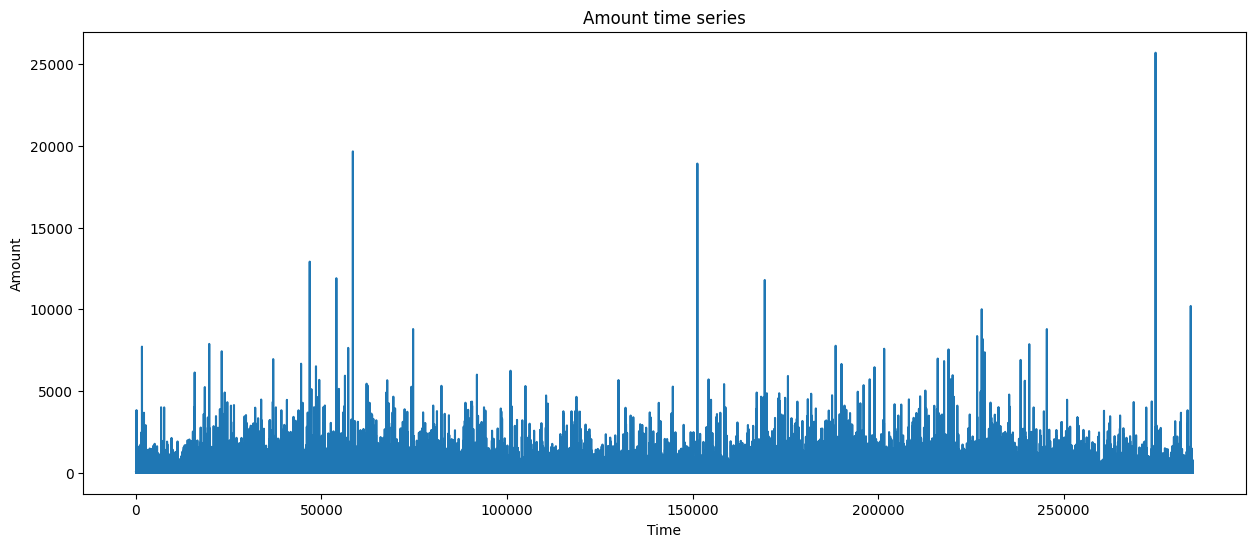

In [23]:
df1.Amount.plot()
plt.xlabel('Time')
plt.ylabel('Amount')
plt.title('Amount time series')
plt.show()

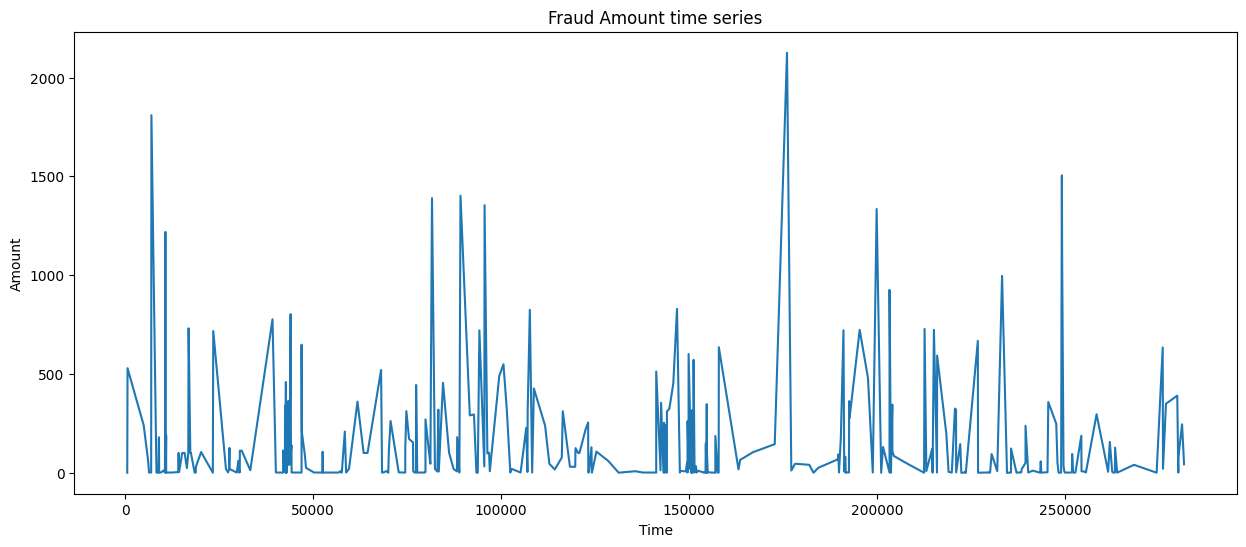

In [24]:
fraud.Amount.plot()
plt.xlabel('Time')
plt.ylabel('Amount')
plt.title('Fraud Amount time series')
plt.show()

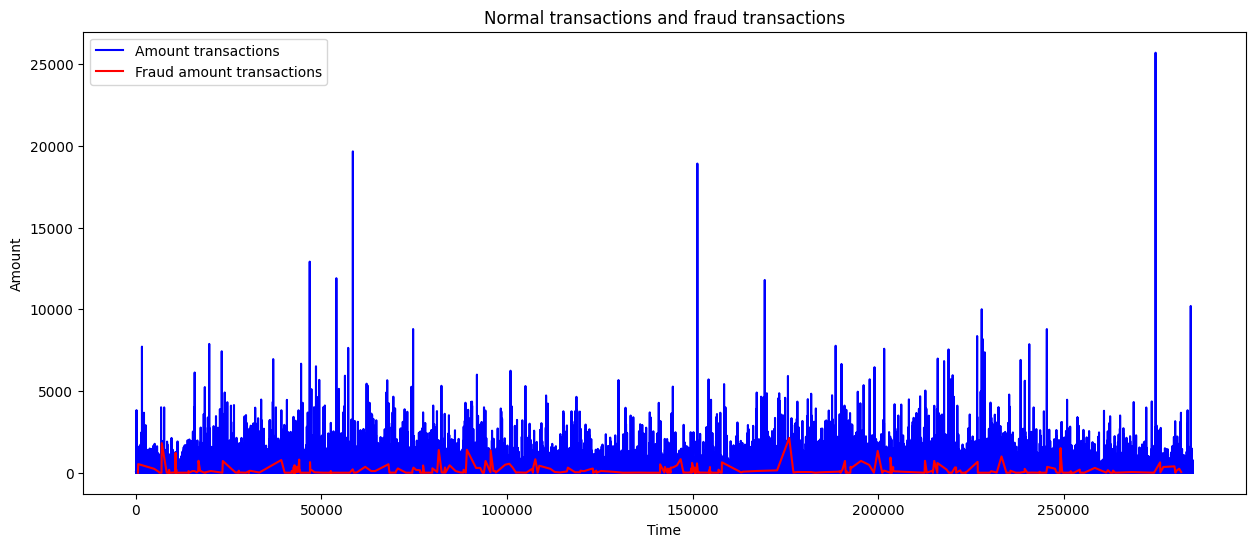

In [25]:
plt.plot(df1.Amount, label='Amount transactions', color='blue')
plt.plot(fraud.Amount, label='Fraud amount transactions', color='red')
plt.legend()
plt.title('Normal transactions and fraud transactions')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.show()

In [36]:
import scipy.stats as stats

- Probability of transactions is be a fraud on credit card: 0.1730%

In [40]:
(fraud.Class.count() / normal.Class.count()) * 100

0.17304750013189596

In [42]:
# Transform em standard scaler

from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

In [44]:
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_mean,Std_mean
26,0:00:23,1.173285,0.353498,0.283905,1.133563,-0.172577,-0.916054,0.369025,-0.327260,-0.246651,...,-0.150487,0.435045,0.724825,-0.337082,0.016368,0.030041,41.88,0,56.966296,56.966296
27,0:00:23,1.322707,-0.174041,0.434555,0.576038,-0.836758,-0.831083,-0.264905,-0.220982,-1.071425,...,-0.037710,0.347151,0.559639,-0.280158,0.042335,0.028822,16.00,0,52.017407,52.017407
28,0:00:23,-0.414289,0.905437,1.727453,1.473471,0.007443,-0.200331,0.740228,-0.029247,-0.593392,...,-0.038500,0.642522,-0.183891,-0.277464,0.182687,0.152665,33.00,0,53.140000,53.140000
29,0:00:23,1.059387,-0.175319,1.266130,1.186110,-0.786002,0.578435,-0.767084,0.401046,0.699500,...,0.014462,0.002951,0.294638,-0.395070,0.081461,0.024220,12.99,0,39.596667,39.596667
30,0:00:24,1.237429,0.061043,0.380526,0.761564,-0.359771,-0.494084,0.006494,-0.133862,0.438810,...,-0.044265,0.079168,0.509136,0.288858,-0.022705,0.011836,17.28,0,35.662593,35.662593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,"1 day, 23:59:46",-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,19.676296,19.676296
284803,"1 day, 23:59:47",-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,20.327037,20.327037
284804,"1 day, 23:59:48",1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,22.804074,22.804074
284805,"1 day, 23:59:48",-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,20.211481,20.211481


In [ ]:
X = df1.drop(columns='Class')
y = df1.Class

In [48]:
X = scaler.fit_transform(X)

In [49]:
X

array([[ 0.59899049,  0.21405953,  0.18729053, ..., -0.18579342,
        -0.60302397, -0.60302397],
       [ 0.67527631, -0.10540266,  0.28664557, ..., -0.28925978,
        -0.69810649, -0.69810649],
       [-0.21152472,  0.5482981 ,  1.1393236 , ..., -0.22129501,
        -0.67653823, -0.67653823],
       ...,
       [ 0.97999436, -0.18243918, -2.14311472, ..., -0.0818473 ,
        -1.2593794 , -1.2593794 ],
       [-0.12276847,  0.32123631,  0.46336448, ..., -0.31324735,
        -1.30919063, -1.30919063],
       [-0.2723418 , -0.11490558,  0.46390998, ...,  0.51432366,
        -1.17256555, -1.17256555]])

In [50]:
# Import vectorial suport regression

from sklearn.svm import SVC

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [69]:
vectorial_poly = SVC(kernel='poly', degree=3)
vectorial_poly.fit(X_train, y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
y_pred_logistic = vectorial_poly.predict(X_test)

In [61]:
from sklearn.metrics import confusion_matrix

In [ ]:
print(confusion_matrix(y_test, y_pred_logistic))

[[56856     4]
 [   28    69]]


In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
print(f'Accuracy: ', accuracy_score(y_test, y_pred_logistic))
print(f'Precision: ', precision_score(y_test, y_pred_logistic))
print(f'Recall: ', recall_score(y_test, y_pred_logistic))
print(f'F-1 score: ', f1_score(y_test, y_pred_logistic))

Accuracy:  0.9994381726565654
Precision:  0.9452054794520548
Recall:  0.711340206185567
F-1 score:  0.8117647058823529


# Model Evaluation Metrics

- Accuracy: 99.94% of all transactions were classified correctly.
- Precision: 94.52% of the transactions predicted as fraudulent were actually frauds.
- Recall: The model detected 71.13% of all fraudulent transactions.
- F1-score: 81.17%, representing the balance between precision and recall.

The Support Vector Classifier (SVC) correctly classified 99.94% of all transactions in the test dataset.

The model achieved a precision of 94.52%, meaning that when it predicts a transaction as fraudulent, it is correct 94.52% of the time. This indicates a very low number of false positives.

The recall of 71.13% means that the model successfully identified 71.13% of all actual fraudulent transactions. In a real-world scenario, these fraudulent transactions could be flagged or blocked by the fraud detection system, while the remaining 28.87% would not be detected.

The F1-score of 81.17% summarizes the trade-off between precision and recall. A good F1-score indicates that the model maintains a strong balance between detecting fraudulent transactions and minimizing false alarms, helping protect the company from financial losses while reducing unnecessary disruptions to legitimate customers.

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [80]:
logistic_model = LogisticRegression()

In [ ]:
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [84]:
y_pred_logistic = logistic_model.predict(X_test)

In [85]:
print(confusion_matrix(y_test, y_pred_logistic))

[[56855     5]
 [   44    53]]


In [86]:
print(f'Accuracy: ', accuracy_score(y_test, y_pred_logistic))
print(f'Precision: ', precision_score(y_test, y_pred_logistic))
print(f'Recall: ', recall_score(y_test, y_pred_logistic))
print(f'F-1 score: ', f1_score(y_test, y_pred_logistic))

Accuracy:  0.9991397018803659
Precision:  0.9137931034482759
Recall:  0.5463917525773195
F-1 score:  0.6838709677419355


# Model Evaluation Metrics

- Accuracy: 99.91% of all transactions were classified correctly.
- Precision: 91.37% of the transactions predicted as fraudulent were actually frauds.
- Recall: The model detected 54.63% of all fraudulent transactions.
- F1-score: 68.37%, representing the balance between precision and recall.

The Logistic regression correctly classified 99.91% of all transactions in the test dataset.

The model achieved a precision of 94.37%, meaning that when it predicts a transaction as fraudulent, it is correct 94.37% of the time. This indicates a very low number of false positives.

The recall of 54.63% means that the model successfully identified 68.38% of all actual fraudulent transactions. In a real-world scenario, these fraudulent transactions could be flagged or blocked by the fraud detection system, while the remaining 31.62% would not be detected.

The F1-score of 68.38% summarizes the trade-off between precision and recall. A good F1-score indicates that the model maintains a strong balance between detecting fraudulent transactions and minimizing false alarms, helping protect the company from financial losses while reducing unnecessary disruptions to legitimate customers.

# Comparation between Suport vector classification and logistic regression:

Support vector classification is 12.79% better then logistic Regression to intercept suspects transactions

The SVC (Support vector classifier) It performed well above expectations for logistic regression; so far, the project's benchmark should be the support vector classifier. Any model that will be evaluated as the best must outperform the SVC to be accepted.